# Sports Exploratory Data Analysis (EDA)

In [32]:
# Automatically reloads modules when you make changes (useful during development)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [33]:
# -------------------------------------------------- imports --------------------------------------------------
import matplotlib.pyplot as plt   # plotting
import pandas as pd               # dataframes
import numpy as np                # numerical operations
import sys, os                    # system & path management
import re                         # regular expressions

# Add parent directory to the path
sys.path.append(os.path.abspath('..'))

# Load data
from src.data import load_data
df_body, df_title, df_subreddits, df_english_pl, df_esports, df_superbowl = load_data()

# Check-up
df_body.head()
df_title.head()
df_subreddits.head()

,SUBREDDIT,EMBEDDING_0,EMBEDDING_1,EMBEDDING_2,EMBEDDING_3,EMBEDDING_4,EMBEDDING_5,EMBEDDING_6,EMBEDDING_7,EMBEDDING_8,...,EMBEDDING_290,EMBEDDING_291,EMBEDDING_292,EMBEDDING_293,EMBEDDING_294,EMBEDDING_295,EMBEDDING_296,EMBEDDING_297,EMBEDDING_298,EMBEDDING_299
0,spiders,0.158972,0.285813,0.226329,-0.183338,-0.163159,-0.188910,0.422705,0.168602,0.178193,...,-0.025041,0.184655,0.111942,-1.125799,0.223129,-0.387323,-0.234882,-0.252297,-0.054315,0.500009
1,askreddit,-0.499114,0.323983,-0.424809,-0.222705,-0.327201,0.412856,1.040088,0.996697,-1.256240,...,0.072151,0.226658,0.535705,0.039861,-0.027087,-0.239952,0.554510,0.676439,-0.328846,0.941547
2,globaloffensivetrade,-0.023145,-1.199374,1.661484,-1.025296,1.424670,-1.179507,-1.035703,0.329301,-0.567272,...,2.998430,-1.235703,-0.326850,4.381238,-1.965378,-2.369674,-0.615389,2.010601,-0.919314,-2.149625
3,fireteams,2.492506,-2.529917,-0.448484,-3.543441,-0.586122,-0.101517,1.837567,-0.215715,-2.460388,...,-1.875214,0.969291,0.497958,2.941132,2.423561,1.315691,-0.959618,0.151845,-0.852492,-0.467526
4,funny,-0.819370,-0.865261,0.301753,0.018787,0.201029,0.070462,0.903895,1.038460,-0.306950,...,1.364194,0.830233,-0.137822,-2.204667,-0.162008,0.390291,-0.556404,0.322684,0.641634,1.320716


In [34]:
df_english_pl

,Season,DateTime,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR
0,2013-14,2014-01-01T00:00:00Z,Arsenal,Cardiff,2,0,H,0.0,0.0,D,...,6.0,2.0,12.0,2.0,6.0,11.0,1.0,2.0,0.0,0.0
1,2013-14,2014-01-01T00:00:00Z,Crystal Palace,Norwich,1,1,D,1.0,1.0,D,...,4.0,5.0,9.0,4.0,12.0,10.0,2.0,1.0,0.0,1.0
2,2013-14,2014-01-01T00:00:00Z,Fulham,West Ham,2,1,H,1.0,1.0,D,...,11.0,3.0,12.0,4.0,6.0,5.0,2.0,1.0,0.0,1.0
3,2013-14,2014-01-01T00:00:00Z,Liverpool,Hull,2,0,H,1.0,0.0,H,...,6.0,0.0,3.0,4.0,15.0,15.0,1.0,2.0,0.0,0.0
4,2013-14,2014-01-01T00:00:00Z,Man United,Tottenham,1,2,A,0.0,1.0,A,...,6.0,4.0,13.0,2.0,7.0,7.0,2.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1284,2016-17,2017-04-29T00:00:00Z,Crystal Palace,Burnley,0,2,A,0.0,1.0,A,...,5.0,3.0,14.0,4.0,11.0,12.0,2.0,0.0,0.0,0.0
1285,2016-17,2017-04-29T00:00:00Z,Southampton,Hull,0,0,D,0.0,0.0,D,...,2.0,1.0,6.0,6.0,9.0,13.0,0.0,3.0,0.0,0.0
1286,2016-17,2017-04-29T00:00:00Z,Stoke,West Ham,0,0,D,0.0,0.0,D,...,4.0,4.0,5.0,3.0,12.0,3.0,1.0,0.0,0.0,0.0
1287,2016-17,2017-04-29T00:00:00Z,Sunderland,Bournemouth,0,1,A,0.0,0.0,D,...,5.0,7.0,6.0,5.0,13.0,9.0,3.0,2.0,0.0,0.0


In [35]:
df_superbowl

,Date,SB,Winner,Winner Pts,Loser,Loser Pts,MVP,Stadium,City,State
0,Feb 5 2017,LI (51),New England Patriots,34,Atlanta Falcons,28,Tom Brady,NRG Stadium,Houston,Texas
1,Feb 7 2016,50,Denver Broncos,24,Carolina Panthers,10,Von Miller,Levi's Stadium,Santa Clara,California
2,Feb 1 2015,XLIX (49),New England Patriots,28,Seattle Seahawks,24,Tom Brady,University of Phoenix Stadium,Glendale,Arizona
3,Feb 2 2014,XLVIII (48),Seattle Seahawks,43,Denver Broncos,8,Malcolm Smith,MetLife Stadium,East Rutherford,New Jersey


In [ ]:
# Define themes
THEMES = {
    # Define sports theme
    'sports': [
        'nba', 'nfl', 'hockey', 'fantasyfootball', 'cfb', 'maddenultimateteam', 'baseball', 'golf', 'patriots', 'collegebasketball', 'seahawks', 'minnesotavikings', 'madden', 'greenbaypackers', 'warriors', 'eagles', 'denverbroncos', 'torontobluejays', '49ers', 'lakers', 'browns', 'oaklandraiders'
    ]
}

# Extract sports theme list
sports_list = THEMES['sports']
sports_list

# Combine all subreddit from dataset
all_subreddits = pd.concat([
    df_title["SOURCE_SUBREDDIT"],
    df_title["TARGET_SUBREDDIT"],
    df_body["SOURCE_SUBREDDIT"],
    df_body["TARGET_SUBREDDIT"]
]).unique()


# -------------------------------------------------- FIND SPORTS SUBREDDITS --------------------------------------------------

# Any keyword appears anywhere (nba --> nba, nba_fanpage --> nba, thenba --> nba)
sports_present = [
    s for s in all_subreddits
    if any(keyword in s.lower() for keyword in sports_list)
]
sports_present

# Whole-word match using regex (nba --> nba, nba_fanpage --> nba)
sports_present_cleaned = []
for s in all_subreddits:
    if not isinstance(s, str):
        continue
    name = s.lower()
    for keyword in sports_list:
        if re.search(rf"\b{keyword}\b", name):
            sports_present_cleaned.append(s)
            break
sports_present_cleaned

# Exact match (nba --> nba)
sports_exact = [s for s in all_subreddits if s.lower() in sports_list]
sports_exact


# -------------------------------------------------- SORTING & COUNTING --------------------------------------------------

# Sort + clean list
sorted(sports_present_cleaned)

# Count the activity of each sports subreddit
sports_counts = (
    pd.concat([
        df_title["SOURCE_SUBREDDIT"],
        df_title["TARGET_SUBREDDIT"],
        df_body["SOURCE_SUBREDDIT"],
        df_body["TARGET_SUBREDDIT"]
    ])
    .value_counts()
    .loc[sports_present_cleaned]
)
sports_counts


greenbaypackers        672
49ers                  601
eagles                 651
oaklandraiders         673
nfl                   4997
cfb                   1941
seahawks               666
hockey                3816
baseball              2360
patriots               609
minnesotavikings       580
nba                   3640
maddenultimateteam     107
lakers                 226
denverbroncos          649
browns                 648
collegebasketball      841
torontobluejays        173
warriors               271
fantasyfootball        448
madden                 178
golf                   199
Name: count, dtype: int64

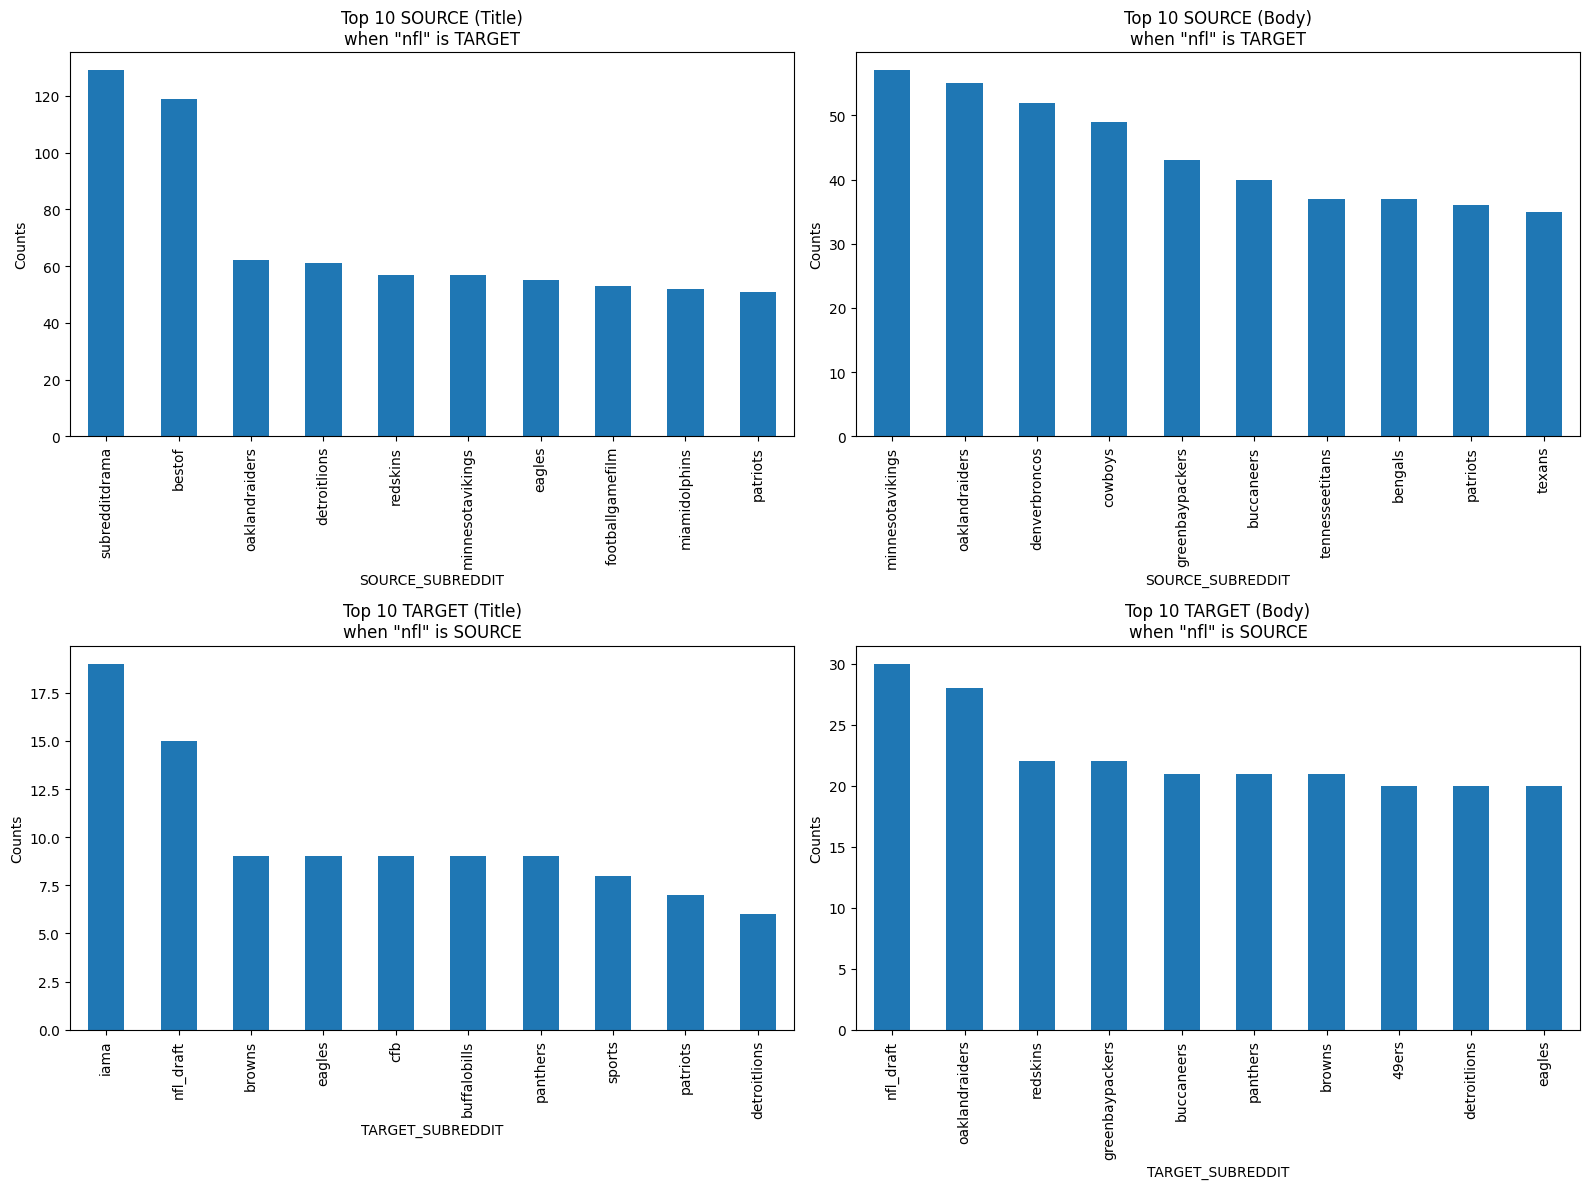

In [ ]:
# Setting the selected subreddit
subreddit = "nfl"
# subreddit = "hockey"
# subbredit = "nba"
# subreddit = "baseball"

top_10_source_title = df_title[df_title["TARGET_SUBREDDIT"]==subreddit]["SOURCE_SUBREDDIT"].value_counts().head(10)
top_10_target_title = df_title[df_title["SOURCE_SUBREDDIT"]==subreddit]["TARGET_SUBREDDIT"].value_counts().head(10)

top_10_source_body = df_body[df_body["TARGET_SUBREDDIT"]==subreddit]["SOURCE_SUBREDDIT"].value_counts().head(10)
top_10_target_body = df_body[df_body["SOURCE_SUBREDDIT"]==subreddit]["TARGET_SUBREDDIT"].value_counts().head(10)

plt.figure(figsize=(16, 12))

# 1. Source Title
plt.subplot(2, 2, 1)
top_10_source_title.plot(kind='bar')
plt.title(f'Top 10 SOURCE (Title)\nwhen "{subreddit}" is TARGET')
plt.ylabel('Counts')

# 2. Source Body
plt.subplot(2, 2, 2)
top_10_source_body.plot(kind='bar')
plt.title(f'Top 10 SOURCE (Body)\nwhen "{subreddit}" is TARGET')
plt.ylabel('Counts')

# 3. Target Title
plt.subplot(2, 2, 3)
top_10_target_title.plot(kind='bar')
plt.title(f'Top 10 TARGET (Title)\nwhen "{subreddit}" is SOURCE')
plt.ylabel('Counts')

# 4. Target Body
plt.subplot(2, 2, 4)
top_10_target_body.plot(kind='bar')
plt.title(f'Top 10 TARGET (Body)\nwhen "{subreddit}" is SOURCE')
plt.ylabel('Counts')

plt.tight_layout()
plt.show()


In [38]:
temp_list = []

string = "baseball"

temp = list(df_body[df_body["SOURCE_SUBREDDIT"].str.contains("baseball", case=False, na=False)].SOURCE_SUBREDDIT.unique())
temp_list.extend(temp)

temp = list(df_body[df_body["TARGET_SUBREDDIT"].str.contains("baseball", case=False, na=False)].TARGET_SUBREDDIT.unique())
temp_list.extend(temp)

temp = list(df_title[df_title["SOURCE_SUBREDDIT"].str.contains("baseball", case=False, na=False)].SOURCE_SUBREDDIT.unique())
temp_list.extend(temp)

temp = list(df_title[df_title["TARGET_SUBREDDIT"].str.contains("baseball", case=False, na=False)].TARGET_SUBREDDIT.unique())
temp_list.extend(temp)

nfl_list = list(set(temp_list))

print(f"Total unique subreddits related to 'baseball': {len(temp_list)}")


Total unique subreddits related to 'baseball': 81


In [39]:
temp_list

['baseballcirclejerk',
 'baseball',
 'fantasybaseball',
 'collegebaseball',
 'junkiebaseball',
 'baseballcards',
 'angelsbaseball',
 'baseballdebates',
 'independentbaseball',
 'baseballtradedeadline',
 'baseballoffseason16',
 'fakebaseball',
 'internationalbaseball',
 'baseballtrivianight',
 'baseballoffseason2017',
 'modernbaseball',
 'baseball',
 'collegebaseball',
 'fantasybaseball',
 'baseballoffseason2014',
 'baseballhof',
 'angelsbaseball',
 'classicbaseball',
 'baseballmogul',
 'baseballoffseason15',
 'baseballdebates',
 'zengmbaseball',
 'independentbaseball',
 'baseballtradedeadline',
 'baseballplayers',
 'ultimatebaseball',
 'baseballoffseason16',
 'internationalbaseball',
 'baseballcirclejerk',
 'baseballnightlypick',
 'baseballscorecards',
 'baseballcirclejerk',
 'baseball',
 'angelsbaseball',
 'fantasybaseball',
 'internationalbaseball',
 'baseballcards',
 'laaabaseball',
 'baseballstats',
 'tabletopbaseball',
 'collegebaseball',
 'baseballhof',
 'anglesbaseball',
 'baseb

In [40]:
nfl_subreddits = [
    'nfl', 'nflcirclejerk', 'nfl_draft', 'nfl_bets',
]

hockey_subreddits = [
    'hockey', 'usahockey', 'hockeyplayers', 'hockeyfandom', 'hockeycirclejerk', 'hockeyjerseys', 'hockeyfandom',
]

nba_subreddits = [
    'nba', 'nbacirclejerk', 'nba_draft',
]

baseball_subreddits = [
    'baseball', 'baseballcirclejerk', 'collegebaseball', 'baseballdebates',
]

sports = ["sports", "nfl", "hockey", "nba", "baseball"]


In [41]:
properties_list = [
    # 'LIWC_FUNCT',
    #  'LIWC_RELAT',
    #  'LIWC_PREP',
    #  'LIWC_COG',
    #  'LIWC_VERB',
    'LIWC_SOC',
    #  'LIWC_PRON',
    'LIWC_AFFECT',
    #  'LIWC_SPACE',
    #  'LIWC_PRES',
    #  'LIWC_ART',
    'LIWC_LEISURE',
    #  'LIWC_AUXVB',
    #  'LIWC_TIME',
    'LIWC_POSEMO',
    #  'LIWC_PPRON',
    #  'LIWC_IPRON',
    #  'LIWC_ADV',
    #  'LIWC_CONJ',
    #  'LIWC_INCL',
    'LIWC_NEGEMO',
    'LIWC_ACHIEV',
    'LIWC_INSIGHT',
    #  'LIWC_QUANT',
    'LIWC_WORK',
    #  'LIWC_CAUSE',
    #  'LIWC_EXCL',
    #  'LIWC_PAST',
    #  'LIWC_TENT',
    'LIWC_BIO'
    'LIWC_PERCEPT',
 ]

# for f in top_30:
#     print(f, PROPERTIES[f])
    

In [42]:
selected_PROPERTIES = {
    # "N_CHARS": "Number of characters", # Total number of characters
    # "N_CHARS_NO_WS": "Number of characters without white space", # Characters excluding whitespace
    # "FRAC_ALPHA": "Fraction alphabetic characters", # Fraction of alphabetic letters
    # "FRAC_DIGIT": "Fraction digits", # Fraction of digits
    # "FRAC_UPPER": "Fraction uppercase characters", # Fraction of uppercase letters
    # "FRAC_WS": "Fraction white space", # Fraction of whitespace characters
    # "FRAC_SPECIAL": "Fraction special characters", # Fraction of punctuation/special chars
    # "N_WORDS": "Number of words", # Total word count
    # "N_UNIQUE_WORDS": "Number of unique words", # Unique word count
    # "N_LONG_WORDS": "Number of long words", # Words with at least 6 characters
    # "AVG_WORD_LEN": "Average word length", # Mean word length
    # "N_UNIQUE_STOP": "Number of unique stopwords", # Unique stopwords count
    # "FRAC_STOP": "Fraction stopwords", # Fraction of tokens that are stopwords
    # "N_SENT": "Number of sentences", # Sentence count
    # "N_LONG_SENT": "Number of long sentences", # Sentences with at least 10 words
    # "AVG_CHAR_SENT": "Average characters per sentence", # Mean characters per sentence
    # "AVG_WORD_SENT": "Average words per sentence", # Mean words per sentence
    # "ARI": "Automated Readability Index", # Readability score
    # "VADER_POS": "VADER Positive", # Positive sentiment score (VADER)
    # "VADER_NEG": "VADER Negative", # Negative sentiment score (VADER)
    # "VADER_COMP": "VADER Compound", # Compound sentiment score (VADER)
    # "LIWC_FUNCT": "LIWC Func. words", # Function words (articles, prepositions, conjunctions)
    # "LIWC_PRON": "LIWC Pronouns", # All pronouns
    # "LIWC_PPRON": "LIWC Pers. pronouns", # Personal pronouns (I, you, he, she, we, they)
    # "LIWC_I": "LIWC I", # First-person singular "I"
    # "LIWC_WE": "LIWC We", # First-person plural "we"
    # "LIWC_YOU": "LIWC You", # Second-person "you"
    # "LIWC_SHEHE": "LIWC SheHe", # Third-person singular (she, he)
    # "LIWC_THEY": "LIWC They", # Third-person plural (they)
    # "LIWC_IPRON": "LIWC Imp. pronouns", # Impersonal/indefinite pronouns (it, one)
    # "LIWC_ART": "LIWC Articles", # Articles (a, an, the)
    # "LIWC_VERB": "LIWC Verbs", # All verb forms
    # "LIWC_AUXVB": "LIWC Aux. verbs", # Auxiliary verbs (be, have, do, modals)
    # "LIWC_PAST": "LIWC Past tense", # Past tense verbs
    # "LIWC_PRES": "LIWC Present tense", # Present tense verbs
    # "LIWC_FUT": "LIWC Future", # Future markers (will, gonna)
    # "LIWC_ADV": "LIWC Adverbs", # Adverbs
    # "LIWC_PREP": "LIWC Prepositions", # Prepositions
    # "LIWC_CONJ": "LIWC Conjunctions", # Conjunctions
    "LIWC_NEG": "LIWC Negation", # Negations (not, no, never)
    "LIWC_QUANT": "LIWC Quantifiers", # Quantifiers (many, few, much)
    "LIWC_NUM": "LIWC Numbers", # Numerals and number words
    "LIWC_SWEAR": "LIWC Swear", # Profanity / swear words
    "LIWC_SOC": "LIWC Social", # Social process words (talk, friend, share)
    "LIWC_FAM": "LIWC Family", # Family-related words
    "LIWC_FRIEND": "LIWC Friends", # Friends / peer-related words
    "LIWC_HUMAN": "LIWC Humans", # References to people / humans
    "LIWC_AFFECT": "LIWC Affect", # Emotion words
    "LIWC_POSEMO": "LIWC Pos. emotion", # Positive emotion words
    "LIWC_NEGEMO": "LIWC Neg. emotion", # Negative emotion words
    "LIWC_ANX": "LIWC Anxiety", # Anxiety-related words (nervous, afraid)
    "LIWC_ANGER": "LIWC Anger", # Anger-related words
    "LIWC_SAD": "LIWC Sadness", # Sadness-related words
    # "LIWC_COG": "LIWC Cogn. processes", # Cognitive process words (think, know)
    "LIWC_INSIGHT": "LIWC Insight", # Insight words (realize, understand)
    # "LIWC_CAUSE": "LIWC Cause", # Causal words (because, therefore)
    # "LIWC_DISCREP": "LIWC Discrepancy", # Discrepancy words (should, would, could)
    # "LIWC_TENT": "LIWC Tentative", # Tentative words (maybe, perhaps)
    "LIWC_CERT": "LIWC Certainty", # Certainty words (definitely, sure)
    "LIWC_INHIB": "LIWC Inhibition", # Inhibition words (stop, prevent, avoid)
    # "LIWC_INCL": "LIWC Inclusion", # Inclusion words (include, with)
    # "LIWC_EXCL": "LIWC Exclusion", # Exclusion words (exclude, without)
    "LIWC_PERCEPT": "LIWC Perceptual", # Perceptual processes (see, hear, feel)
    "LIWC_SEE": "LIWC See", # Vision-related words
    "LIWC_HEAR": "LIWC Hear", # Hearing-related words
    "LIWC_FEEL": "LIWC Feel", # Sensation / feeling words
    "LIWC_BIO": "LIWC Biological", # Biological process words (eat, sleep)
    "LIWC_BODY": "LIWC Body", # Body-part words (arm, head)
    "LIWC_HEALTH": "LIWC Health", # Health-related words
    "LIWC_SEX": "LIWC Sexual", # Sexual content words
    "LIWC_INGEST": "LIWC Ingest", # Eating / drinking words (eat, drink)
    # "LIWC_RELAT": "LIWC Relativity", # Relativity / relational words (near, far)
    "LIWC_MOTION": "LIWC Motion", # Motion verbs (go, move, travel)
    "LIWC_SPACE": "LIWC Space", # Spatial / location words (left, above)
    "LIWC_TIME": "LIWC Time", # Temporal words (when, day, year)
    "LIWC_WORK": "LIWC Work", # Work and occupational words
    "LIWC_ACHIEV": "LIWC Achievement", # Achievement / goal words
    "LIWC_LEISURE": "LIWC Leisure", # Leisure and recreation words
    "LIWC_HOME": "LIWC Home", # Home / domestic words
    "LIWC_MONEY": "LIWC Money", # Money / finance words
    "LIWC_RELIG": "LIWC Religion", # Religion and spirituality words
    "LIWC_DEATH": "LIWC Death", # Death-related words
    "LIWC_ASSENT": "LIWC Assent", # Agreement / approval words (yes, okay)
    "LIWC_DISSENT": "LIWC Dissent", # Disagreement / opposition words (no, oppose)
    "LIWC_NONFLU": "LIWC Nonfluencies", # Non-fluencies (uh, um, repetitions)
    "LIWC_FILLER": "LIWC Filler", # Filler phrases (you know, I mean)
}

,Feature,Mean_Title,Max_Title,Sum_Title,Std_Title,Mean_Body,Max_Body,Sum_Body,Std_Body
4,LIWC_SOC,0.04971,0.50,467.73,0.06409,0.07301,0.32,457.55,0.03123
29,LIWC_WORK,0.01627,0.50,153.06,0.03728,0.04270,0.19,267.60,0.02303
27,LIWC_SPACE,0.04700,0.45,442.25,0.05798,0.03690,0.17,231.24,0.02685
8,LIWC_AFFECT,0.04205,0.57,395.67,0.05853,0.03392,0.25,212.57,0.02735
28,LIWC_TIME,0.04664,0.50,438.88,0.07210,0.03048,0.19,191.04,0.02381
31,LIWC_LEISURE,0.03243,0.50,305.20,0.05118,0.02483,0.17,155.63,0.02402
9,LIWC_POSEMO,0.02664,0.50,250.67,0.04635,0.02382,0.17,149.25,0.02149
21,LIWC_BIO,0.00968,0.43,91.09,0.03162,0.02007,0.26,125.80,0.02244
1,LIWC_QUANT,0.01322,0.33,124.36,0.03042,0.01764,0.15,110.53,0.01657
30,LIWC_ACHIEV,0.02001,0.47,188.26,0.03946,0.01699,0.19,106.50,0.01706


['LIWC_SOC', 'LIWC_WORK', 'LIWC_SPACE', 'LIWC_AFFECT', 'LIWC_TIME', 'LIWC_LEISURE', 'LIWC_POSEMO', 'LIWC_BIO', 'LIWC_QUANT', 'LIWC_ACHIEV']


<Axes: title={'center': 'LIWC Properties Heatmap (Body) (Normalized)'}>

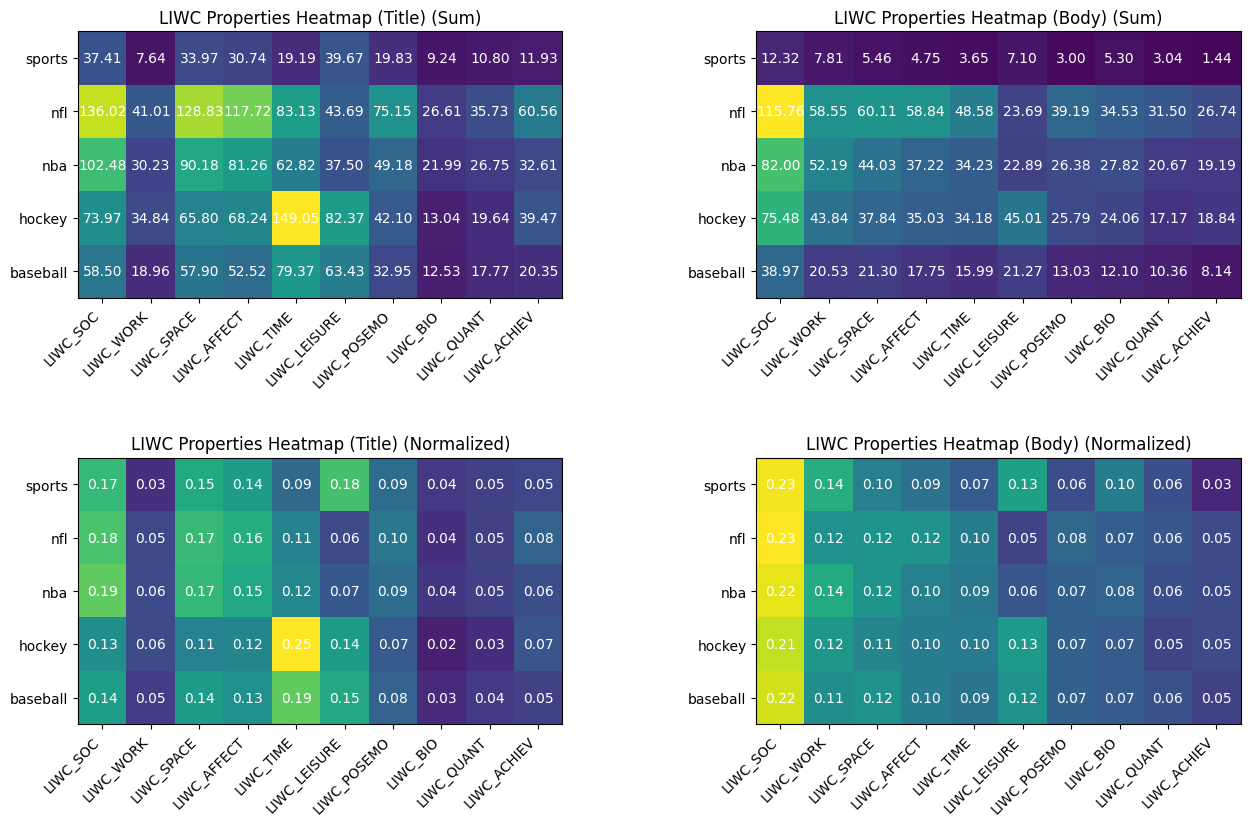

In [43]:
from week1_Yuri import plot_liwc_heatmaps_for_features_list
from src.consts import PROPERTIES
from week1_Yuri import get_dataframe_features

subreddits_list = sports
df_features = get_dataframe_features(
    df_title, df_body, selected_PROPERTIES.keys(), subreddits_list
)
display(df_features.sort_values(
    by=['Sum_Body', 'Sum_Title',], ascending=False
).head(10))

# VADER sentiment
# properties_list = [ "VADER_POS", "VADER_NEG", "VADER_COMP",]

# LIWC properties
properties_list = df_features.sort_values(
    by=['Sum_Body', 'Sum_Title',], ascending=False
).head(10)["Feature"].tolist()
print(properties_list)

fig, ax = plt.subplots(2, 2, figsize = (15, 9))
plt.subplots_adjust(hspace=0.6, wspace=0.4)

plot_liwc_heatmaps_for_features_list(
    ax[0, 0], df_title, sports, properties_list, title='LIWC Properties Heatmap (Title)')

plot_liwc_heatmaps_for_features_list(
    ax[0, 1], df_body, sports, properties_list, title='LIWC Properties Heatmap (Body)')

plot_liwc_heatmaps_for_features_list(
    ax[1, 0], df_title, sports, properties_list, title='LIWC Properties Heatmap (Title)', normalize=True)

plot_liwc_heatmaps_for_features_list(
    ax[1, 1], df_body, sports, properties_list, title='LIWC Properties Heatmap (Body)', normalize=True)


<Axes: title={'center': 'Baseball (Normalized)'}>

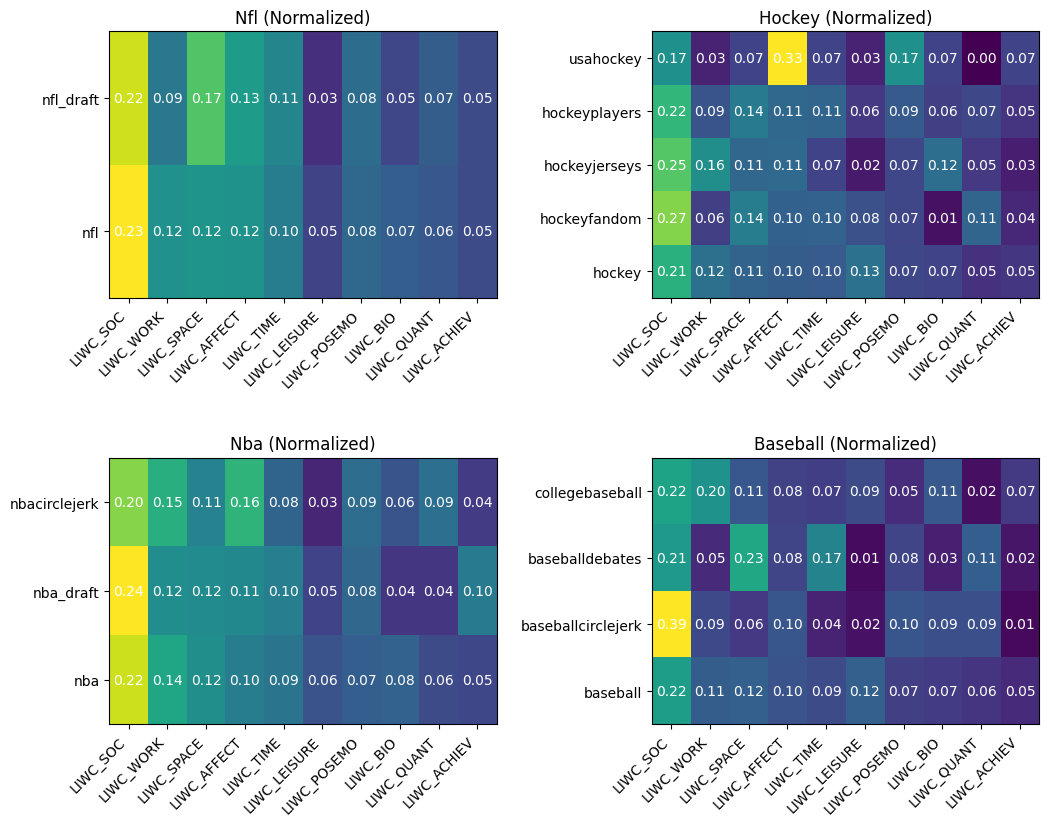

In [44]:
from week1_Yuri import plot_liwc_heatmaps_for_features_list

fig, ax = plt.subplots(2, 2, figsize = (12, 9))
plt.subplots_adjust(hspace=0.6, wspace=0.4)

# properties_list = df_features_liwc.sort_values(by=['Sum_Title', 'Sum_Body'], ascending=False).head(10)["Feature"].tolist()

plot_liwc_heatmaps_for_features_list(
    ax[0][0], df_body, nfl_subreddits, properties_list, title='Nfl',normalize=True)

plot_liwc_heatmaps_for_features_list(
    ax[0][1], df_body, hockey_subreddits, properties_list, title='Hockey', normalize=True)

plot_liwc_heatmaps_for_features_list(
    ax[1][0], df_body, nba_subreddits, properties_list, title='Nba', normalize=True)

plot_liwc_heatmaps_for_features_list(
    ax[1][1], df_body, baseball_subreddits, properties_list, title='Baseball', normalize=True)


Title
3050


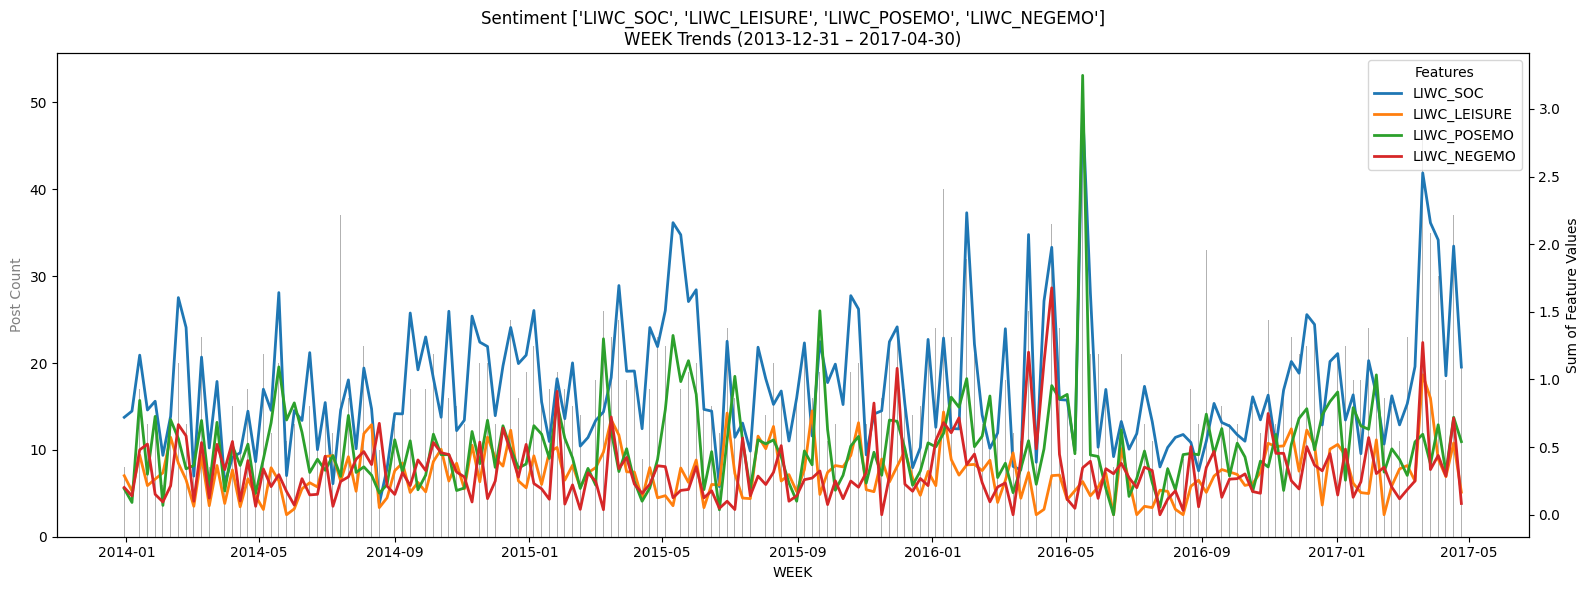

Body
2624


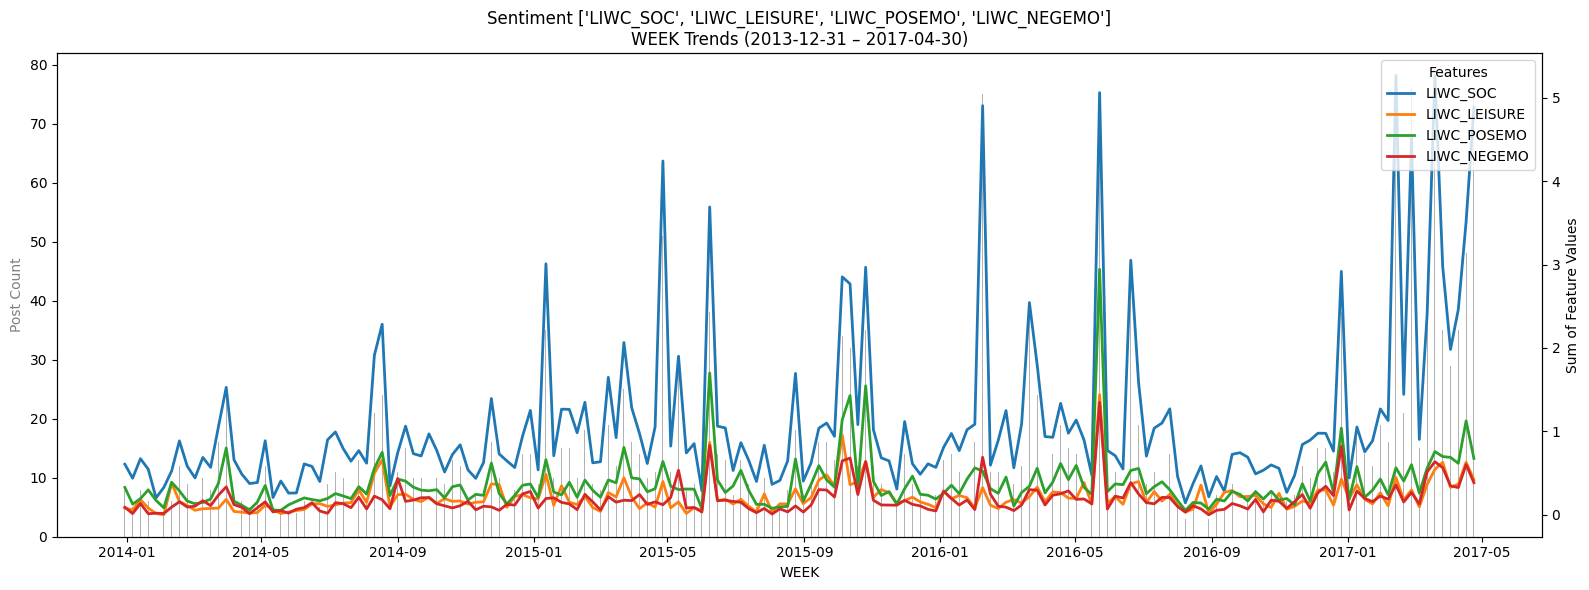

In [45]:
from week1_Yuri import plot_subreddits_features_trend 

subreddits_list = nfl_subreddits

start_time = "2013-12-31"
end_time = "2017-04-30"

features_list = [
    "LIWC_SOC",
    "LIWC_LEISURE",
    "LIWC_POSEMO",
    "LIWC_NEGEMO",
]

period = "W"  # "D" for daily, "W" for weekly, "M" for monthly, "Q" for quarterly, "Y" for yearly

print("Title")
plot_subreddits_features_trend(df_title, subreddits_list, start_time, end_time, features_list, period)

print("Body")
plot_subreddits_features_trend(df_body, subreddits_list, start_time, end_time, features_list, period)
